# Estudo

### Análise exploratória

In [47]:
import pandas as pd

# 1. Carregando os dados
caminho_ficheiro = 'data/lol_match_stats/MatchStatsTbl.csv'
df = pd.read_csv(caminho_ficheiro)

# 2. Primeiras linhas
print("--- Primeiras 5 linhas do nosso conjunto de dados ---")
print(df.head())

# 3. Estrutura dos dados
print("\n--- Informações sobre as colunas ---")
print(df.info())

# 4. Variável Alvo
print("\n--- Distribuição de Vitórias (1) e Derrotas (0) ---")
print(df['Win'].value_counts())

--- Primeiras 5 linhas do nosso conjunto de dados ---
   MatchStatsId  SummonerMatchFk  MinionsKilled  DmgDealt  DmgTaken  \
0             1                1             30      4765     12541   
1             2                2             29      8821     14534   
2             3                3             34      6410     19011   
3             4                4             51     22206     14771   
4             5                5              0     39106     33572   

   TurretDmgDealt  TotalGold    Lane  Win  item1  ...  PrimarySlot3  \
0               0       7058  BOTTOM    0   3870  ...          8453   
1               1       9618  BOTTOM    0   3870  ...          8453   
2               3       9877  BOTTOM    1   3870  ...          8237   
3               3      12374    NONE    1   6655  ...          8106   
4               0      15012     TOP    1   4015  ...             0   

   SecondarySlot1  SecondarySlot2  SummonerSpell1  SummonerSpell2  \
0            8345      

**Conclusão**: Tentarei criar um modelo que preverá a probabilidade de um jogador ganhar a partida com base em:

- Quantidade de ouro;

- Dano;

- Quantidade de kills;

- Quantidade de mortes;

- Quantidade de assistências;

- Lane escolhida.

**Alguns valores nulos na coluna de lane que podem impactar a análise**

### Limpeza de dados


In [48]:
# 1. Carregando os dados
df = pd.read_csv('data/lol_match_stats/MatchStatsTbl.csv')

# 2. Coluna Lane, incluindo os nulos (NaN)
print("--- Valores na coluna Lane ANTES da limpeza ---")
print(df['Lane'].value_counts(dropna=False)) # O dropna=False força o pandas a nos mostrar os nulos!

# 3. Limpeza de Dados: Remover as linhas onde a coluna 'Lane' é nula
df_limpo = df.dropna(subset=['Lane'])

# 4. Seleção de Features: Escolher apenas o que importa para o modelo
# Ouro, Dano, KDA (Abates/Mortes/Assistências) e a Rota.
colunas_importantes = ['Win', 'TotalGold', 'DmgDealt', 'kills', 'deaths', 'assists', 'Lane']
df_modelo = df_limpo[colunas_importantes]

print("\n--- Informações após a limpeza ---")
print(f"Quantidade de partidas válidas (linhas): {df_modelo.shape[0]}")
print(df_modelo.head())


--- Valores na coluna Lane ANTES da limpeza ---
Lane
NaN        177309
BOTTOM     128258
MIDDLE     107962
TOP        104169
JUNGLE     101660
UTILITY     60501
NONE        52435
SUPPORT        14
Name: count, dtype: int64

--- Informações após a limpeza ---
Quantidade de partidas válidas (linhas): 554999
   Win  TotalGold  DmgDealt  kills  deaths  assists    Lane
0    0       7058      4765      0       2       12  BOTTOM
1    0       9618      8821      2       5       23  BOTTOM
2    1       9877      6410      0       5       22  BOTTOM
3    1      12374     22206      8       4       35    NONE
4    1      15012     39106     13       8        2     TOP


**Conclusão:** identificada pecularidade nos dados quando se trata de suporte, pesquisando encontrei as seguintes entradas sobre a API da Riot Games: 
- Ela chama o Suporte de UTILITY.
- Como o Suporte anda muito pelo mapa (roaming) e não mata muitos minions (farm), o algoritmo da Riot muitas vezes fica confuso e não consegue identificar a rota daquele jogador, classificando-o como NONE.

Somando os valores de SUPPORT, UTLITY e NONE chegamos a uma contagem parecida com as outras lanes, como toda partida deve possuir as 5 rotas, ficamos com:

- BOTTOM:    128258

- MIDDLE:     107962

- TOP:        104169

- JUNGLE:     101660

- SUPPORT: 112.950

In [49]:
# Remover os nulos reais (NaN)
df_limpo = df.dropna(subset=['Lane']).copy()

# 2. Unificando a role de Suporte
# Vamos substituir "UTILITY" e string "NONE" por "SUPPORT"
df_limpo['Lane'] = df_limpo['Lane'].replace(['UTILITY', 'NONE'], 'SUPPORT')

print("--- Novas contagens da coluna Lane ---")
print(df_limpo['Lane'].value_counts())

# 3. Seleção de Colunas
colunas_importantes = ['Win', 'TotalGold', 'DmgDealt', 'kills', 'deaths', 'assists', 'Lane']
df_modelo = df_limpo[colunas_importantes]

# 4. Transformando Texto em Número (One-Hot Encoding)
df_final = pd.get_dummies(df_modelo, columns=['Lane'], dtype=int)

print("\n--- Como ficou a nossa tabela final para a IA ---")
print(df_final.head())

--- Novas contagens da coluna Lane ---
Lane
BOTTOM     128258
SUPPORT    112950
MIDDLE     107962
TOP        104169
JUNGLE     101660
Name: count, dtype: int64

--- Como ficou a nossa tabela final para a IA ---
   Win  TotalGold  DmgDealt  kills  deaths  assists  Lane_BOTTOM  Lane_JUNGLE  \
0    0       7058      4765      0       2       12            1            0   
1    0       9618      8821      2       5       23            1            0   
2    1       9877      6410      0       5       22            1            0   
3    1      12374     22206      8       4       35            0            0   
4    1      15012     39106     13       8        2            0            0   

   Lane_MIDDLE  Lane_SUPPORT  Lane_TOP  
0            0             0         0  
1            0             0         0  
2            0             0         0  
3            0             1         0  
4            0             0         1  


### Treino de modelo Inicial - Regressão Logística

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Separar o Y do X
X = df_final.drop('Win', axis=1) # O 'X' tem tudo (Ouro, Kills, Lane...), menos a coluna 'Win'
y = df_final['Win']              # O 'y' é APENAS a coluna 'Win' (a resposta final)

# 2. Dividir os dados de Treino e Teste (80%/20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Vamos treinar com {len(X_treino)} partidas e testá-la com {len(X_teste)} partidas.\n")

# 3. Inicializar o modelo
# Usamos max_iter=1000 para dar tempo suficiente ao modelo para fazer os cálculos matemáticos
modelo = LogisticRegression(max_iter=1000)

# 4. Treino
print("A treinar o modelo... (isto pode demorar uns segundinhos)")
modelo.fit(X_treino, y_treino)

# 5. Final
previsoes = modelo.predict(X_teste)

# 6. Avaliação
acuracia = accuracy_score(y_teste, previsoes)
print(f"--- RESULTADO DO EXAME FINAL ---")
print(f"Acurácia (Taxa de Acerto): {acuracia * 100:.2f}%")

Vamos treinar a IA com 443999 partidas e testá-la com 111000 partidas.

A treinar o modelo... (isto pode demorar uns segundinhos)
--- RESULTADO DO EXAME FINAL ---
Acurácia (Taxa de Acerto): 77.02%


### Matriz de confusão:
- Verdadeiros Positivos (TP): A IA disse que ias ganhar, e tu ganhaste. (Acerto!)

- Verdadeiros Negativos (TN): A IA disse que ias perder, e tu perdeste. (Acerto!)

- Falsos Positivos (FP): A IA disse que ias ganhar, mas tu perdeste. (Erro otimista)

- Falsos Negativos (FN): A IA disse que ias perder, mas tu ganhaste numa reviravolta épica! (Erro pessimista)

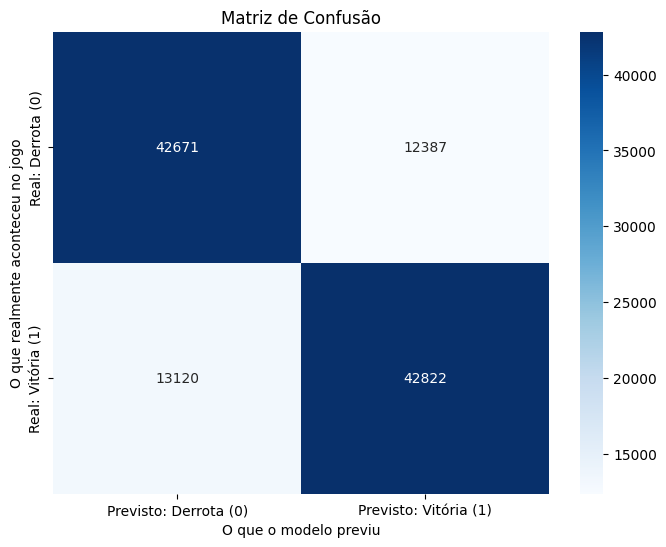

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calcular a Matriz de Confusão
matriz = confusion_matrix(y_teste, previsoes)

# 2. Desenhar um gráfico Heatmap
plt.figure(figsize=(8, 6))
# annot=True mostra os números, fmt='d' garante que são números inteiros
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Derrota (0)', 'Previsto: Vitória (1)'],
            yticklabels=['Real: Derrota (0)', 'Real: Vitória (1)'])

plt.title('Matriz de Confusão')
plt.xlabel('O que o modelo previu')
plt.ylabel('O que realmente aconteceu no jogo')

# 3. Mostrar o gráfico na tela
plt.show()

**Conclusão:** Modelo com 77.02% de acurácia, mas com uma quantidade um pouco maior de falsos negativos, incluindo mais váriaveis em uma segunda versão para tentar corrigir o pessimismo do modelo

--- RESULTADO DO NOVO ORÁCULO ---
Nova Acurácia: 77.41%


C:\Users\joaov\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


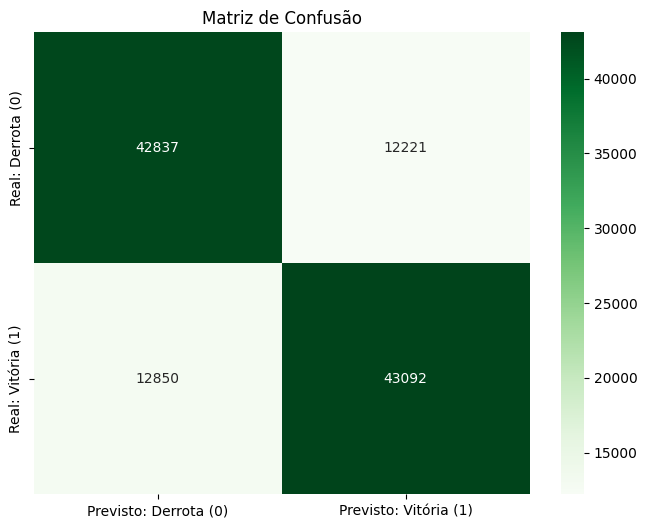

In [52]:
# 1. Colunas novas: Adicionando objetivos do jogo e placar de visão
colunas_melhoradas = ['Win', 'TotalGold', 'DmgDealt', 'kills', 'deaths', 'assists', 'Lane', 'DragonKills', 'BaronKills', 'visionScore']
df_modelo_v2 = df_limpo[colunas_melhoradas]

# 2. One-Hot Encoding
df_final_v2 = pd.get_dummies(df_modelo_v2, columns=['Lane'], dtype=int)

# 3. Separar X e y e Dividir Treino/Teste
X = df_final_v2.drop('Win', axis=1)
y = df_final_v2['Win']
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinar a IA (Aumentamos o max_iter porque a matemática ficou mais complexa)
modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_treino, y_treino)

# 5. Avaliar o Novo Modelo
previsoes = modelo.predict(X_teste)
nova_acuracia = accuracy_score(y_teste, previsoes)
print(f"--- RESULTADO DO NOVO ORÁCULO ---")
print(f"Nova Acurácia: {nova_acuracia * 100:.2f}%")

# 6. Gerar a Nova Matriz
matriz = confusion_matrix(y_teste, previsoes)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Greens', # Mudei para verde para comemorarmos a melhoria!
            xticklabels=['Previsto: Derrota (0)', 'Previsto: Vitória (1)'],
            yticklabels=['Real: Derrota (0)', 'Real: Vitória (1)'])
plt.title('Matriz de Confusão')
plt.show()

**Conclusão:** Devido ao erro de máximo de iterações, vamos adicionar o StandardScaler do sklearn para ensinar ao modelo a escala dos dados. V2 continua com o número de falsos negativos bem próximo a V1.

A treinar o modelo com dados escalados...
--- RESULTADO COM FEATURE SCALING ---
Acurácia Final: 77.43%


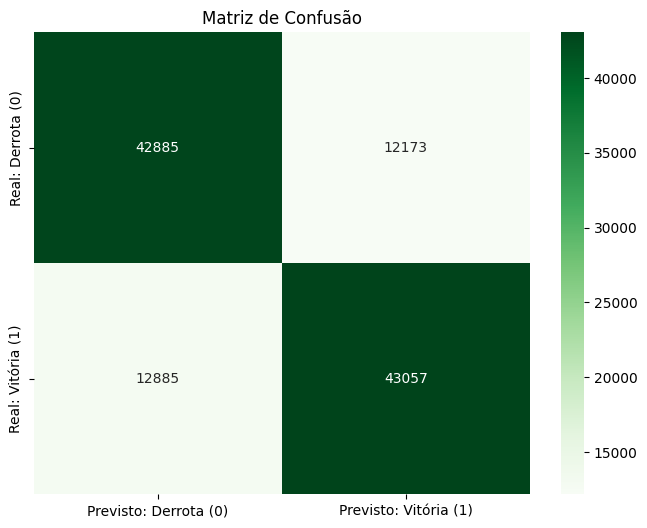

In [53]:
from sklearn.preprocessing import StandardScaler

# 1. Separar X e y
X = df_final_v2.drop('Win', axis=1)
y = df_final_v2['Win']

# 2. Dividir em Treino e Teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()

# O 'fit_transform' aprende a escala com o Treino e já a aplica
X_treino_escalado = scaler.fit_transform(X_treino)

# O 'transform' apenas aplica a escala aprendida aos dados de Teste (Exame Final)
X_teste_escalado = scaler.transform(X_teste)

# 4. Treino
modelo = LogisticRegression(max_iter=100)
print("A treinar o modelo com dados escalados...")
modelo.fit(X_treino_escalado, y_treino)

# 5. Avaliar
previsoes = modelo.predict(X_teste_escalado)
nova_acuracia = accuracy_score(y_teste, previsoes)
print(f"--- RESULTADO COM FEATURE SCALING ---")
print(f"Acurácia Final: {nova_acuracia * 100:.2f}%")

# 6. Gerar a Nova Matriz
matriz = confusion_matrix(y_teste, previsoes)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Greens', # Mudei para verde para comemorarmos a melhoria!
            xticklabels=['Previsto: Derrota (0)', 'Previsto: Vitória (1)'],
            yticklabels=['Real: Derrota (0)', 'Real: Vitória (1)'])
plt.title('Matriz de Confusão')
plt.show()

**Conclusão:** Aviso de máximo de iterações ajustado, tempo de treino de modelo passou de ~30 segundos para menos de 1 segundo, porém modelo continua pessimista. Por não se tratar de algo necessariamente linear, tendo em vista que um time que estava atrás pode virar completamente o jogo, trocarei o algoritmo para Random Forest com o objetivo de capturar essas nuances.

# Random Forest

Treinando modelo
--- RESULTADO DA FLORESTA ALEATÓRIA ---
Acurácia Final: 78.68%


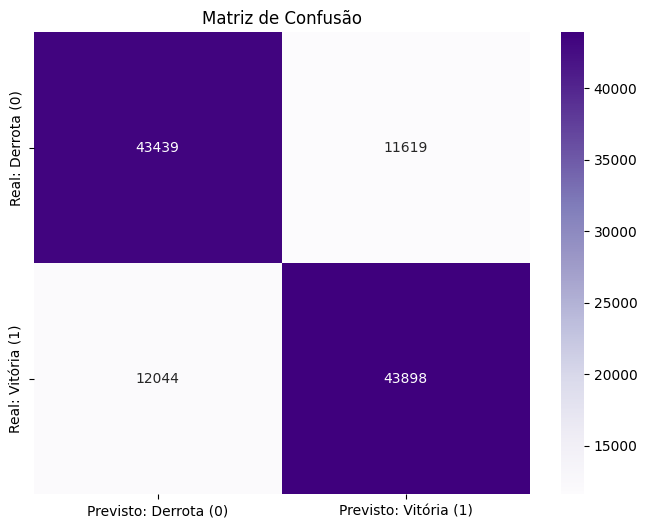

In [54]:
from sklearn.ensemble import RandomForestClassifier

# 4. Parâmetros
# n_estimators=100 (100 árvores de decisão)
# max_depth=12 (Profundidade das árvores (para não demorar muito e não decorar os dados))
# n_jobs=-1 (Usa todos os núcleos do processador)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

print("Treinando modelo")
modelo_rf.fit(X_treino_escalado, y_treino)

previsoes_rf = modelo_rf.predict(X_teste_escalado)

# 6. Avaliar a nova nota e desenhar a Matriz
nova_acuracia_rf = accuracy_score(y_teste, previsoes_rf)
print(f"--- RESULTADO DA FLORESTA ALEATÓRIA ---")
print(f"Acurácia Final: {nova_acuracia_rf * 100:.2f}%")

# Matriz de Confusão para a Floresta
matriz_rf = confusion_matrix(y_teste, previsoes_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Purples', # Roxo para o nosso novo modelo!
            xticklabels=['Previsto: Derrota (0)', 'Previsto: Vitória (1)'],
            yticklabels=['Real: Derrota (0)', 'Real: Vitória (1)'])
plt.title('Matriz de Confusão')
plt.show()


--- Importância das Variáveis ---
       Variável  Importância (%)
3        deaths        41.526972
4       assists        22.106726
2         kills        11.607164
0     TotalGold         8.309936
1      DmgDealt         4.432475
7   visionScore         3.880538
6    BaronKills         2.490632
5   DragonKills         2.220234
9   Lane_JUNGLE         1.398518
12     Lane_TOP         0.876511


C:\Users\joaov\AppData\Local\Temp\ipykernel_816\4060190469.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância (%)', y='Variável', data=df_importancias, palette='magma')


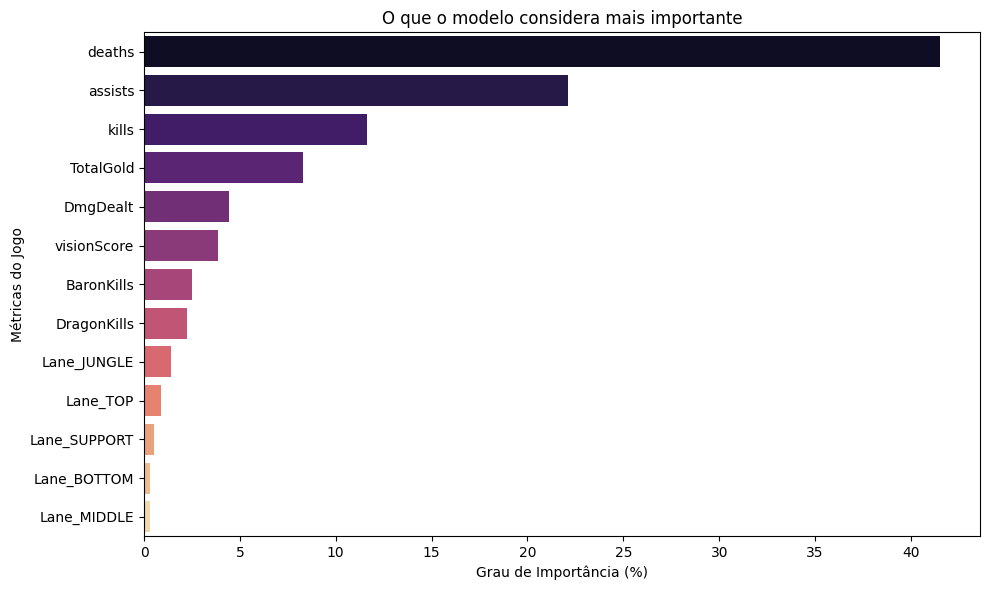

In [55]:
# 7. Feature Importance
importancias = modelo_rf.feature_importances_

# Criar uma tabela com o nome da coluna e o seu "peso" na decisão
df_importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância (%)': importancias * 100 # Multiplicamos por 100 para ver em percentagem
})

# Ordenar do mais importante para o menos importante
df_importancias = df_importancias.sort_values(by='Importância (%)', ascending=False)

print("\n--- Importância das Variáveis ---")
print(df_importancias.head(10)) # Mostra o Top 10

# Desenhar um gráfico de barras para visualizar melhor
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância (%)', y='Variável', data=df_importancias, palette='magma')
plt.title('O que o modelo considera mais importante')
plt.xlabel('Grau de Importância (%)')
plt.ylabel('Métricas do Jogo')
plt.tight_layout()
plt.show()

In [56]:
import pandas as pd

# Preencha com os dados da partida
dados_nova_partida = {
    'TotalGold': [12113],
    'DmgDealt': [19974],
    'kills': [9],
    'deaths': [6],
    'assists': [16],
    'DragonKills': [4],
    'BaronKills': [1],
    'visionScore': [25],
    'Lane_BOTTOM': [0],
    'Lane_JUNGLE': [1],
    'Lane_MIDDLE': [0],
    'Lane_SUPPORT': [0],
    'Lane_TOP': [0]
}

df_novo_X = pd.DataFrame(dados_nova_partida)

df_novo_X = df_novo_X[X.columns]

novo_X_escalado = scaler.transform(df_novo_X)

previsao_Y = modelo_rf.predict(novo_X_escalado)

probabilidade = modelo_rf.predict_proba(novo_X_escalado)[0]

# 3. Imprimir o resultado de forma elegante
print("\n" + "="*40)
print("🔮 CONSULTANDO O ORÁCULO...")
print("="*40)

if previsao_Y[0] == 1:
    print("Resultado: VITÓRIA! (GG WP) 🏆")
    print(f"Certeza do Oráculo: {probabilidade[1] * 100:.2f}%")
else:
    print("Resultado: DERROTA! (Mais sorte na próxima) 💀")
    print(f"Certeza do Oráculo: {probabilidade[0] * 100:.2f}%")


🔮 CONSULTANDO O ORÁCULO...
Resultado: VITÓRIA! (GG WP) 🏆
Certeza do Oráculo: 92.77%


**Integração com API da Riot para pegar última partida do usuário**

In [58]:
import requests

# Nota: Certifique-se de que as variáveis `X`, `scaler` e `modelo_rf` 
# já foram carregadas ou treinadas antes de rodar este bloco.

def extrair_status_ultima_partida(puuid, api_key, region="americas"):
    headers = {
        "X-Riot-Token": api_key
    }

    url_match_ids = f"https://{region}.api.riotgames.com/lol/match/v5/matches/by-puuid/{puuid}/ids?start=0&count=1"
    resposta_ids = requests.get(url_match_ids, headers=headers)

    if resposta_ids.status_code != 200:
        return f"Erro ao buscar o ID da partida: {resposta_ids.status_code} - {resposta_ids.text}"

    match_ids = resposta_ids.json()

    if not match_ids:
        return "Nenhuma partida encontrada para este PUUID."

    last_match_id = match_ids[0]
    print(f"ID da partida encontrada: {last_match_id}")

    url_match = f"https://{region}.api.riotgames.com/lol/match/v5/matches/{last_match_id}"
    resposta_match = requests.get(url_match, headers=headers)

    if resposta_match.status_code != 200:
        return f"Erro ao buscar os detalhes da partida: {resposta_match.status_code}"

    match_data = resposta_match.json()
    participantes = match_data['info']['participants']

    for participant in participantes:
        if participant['puuid'] == puuid:
            status_jogador = {
                'TotalGold': participant.get('goldEarned', 0),
                'DmgDealt': participant.get('totalDamageDealtToChampions', 0),
                'kills': participant.get('kills', 0),
                'deaths': participant.get('deaths', 0),
                'assists': participant.get('assists', 0),
                'DragonKills': participant.get('dragonKills', 0),
                'BaronKills': participant.get('baronKills', 0),
                'visionScore': participant.get('visionScore', 0),
                'Lane': participant.get('teamPosition', 'N/A')
            }

            # CORREÇÃO 1: Colocar dentro de uma lista para o pandas aceitar
            df_status = pd.DataFrame([status_jogador])

            df_status['Lane'] = df_status['Lane'].replace(['UTILITY', 'NONE'], 'SUPPORT')
            df_status = pd.get_dummies(df_status, columns=['Lane'], dtype=int)

            return df_status

    return "Jogador não encontrado nos registros dessa partida."

# ==========================================
# Exemplo de Uso
# ==========================================
if __name__ == "__main__":
    MEU_PUUID = "------"
    MINHA_API_KEY = "----"

    df_novo_X = extrair_status_ultima_partida(MEU_PUUID, MINHA_API_KEY)
    
    print(df_novo_X)
    # Verifica se a função retornou um DataFrame (sucesso) ou uma string de erro
    if isinstance(df_novo_X, pd.DataFrame):

        # CORREÇÃO 2: Garantir que todas as colunas do treino (X.columns) existam aqui
        # As colunas que faltarem receberão o valor 0
        df_novo_X = df_novo_X.reindex(columns=X.columns, fill_value=0)

        novo_X_escalado = scaler.transform(df_novo_X)

        previsao_Y = modelo_rf.predict(novo_X_escalado)
        probabilidade = modelo_rf.predict_proba(novo_X_escalado)[0]

        print("\n" + "="*40)
        print("🔮 CONSULTANDO O ORÁCULO...")
        print("="*40)

        if previsao_Y[0] == 1:
            print("Resultado: VITÓRIA! (GG WP) 🏆")
            print(f"Certeza do Oráculo: {probabilidade[1] * 100:.2f}%")
        else:
            print("Resultado: DERROTA! (Mais sorte na próxima) 💀")
            print(f"Certeza do Oráculo: {probabilidade[0] * 100:.2f}%")
    else:
        print(df_novo_X) # Imprime o erro caso não encontre a partida/jogador

ID da partida encontrada: BR1_3244619165
   TotalGold  DmgDealt  kills  deaths  assists  DragonKills  BaronKills  \
0      13285     42231     10       6        8            0           0   

   visionScore  Lane_  
0            0      1  

🔮 CONSULTANDO O ORÁCULO...
Resultado: VITÓRIA! (GG WP) 🏆
Certeza do Oráculo: 75.32%
